# Tecplot `.plt`, Nastran coordinate systems and plies, and the missing halves of Fluent, Elmer and FEBio

Added in v16.10.0:

- **Tecplot binary `.plt`** is read through the `tecplot` format, and ordered (I, IJ, IJK) zones are read in ASCII and binary files alike.
- **Nastran HDF5 and OP2** results apply the `CORD*` coordinate systems, moving GRIDs to the basic system and rotating their vector results, and read the values beyond an element's centre: `@corner`, `@ply` and `@station` arrays and the grid point forces.
- **Fluent `.msh`** is written face-based, the layout Fluent reads.
- **Elmer** meshes are read from ElmerGrid's binary files, and a mesh with `partition:part` labels is written as a `partitioning.N` directory ElmerSolver runs in parallel.
- **FEBio** `.feb` writes point and cell data as `<MeshData>`, and `.xplt` plot files read surface variables on facet blocks and remeshed runs one mesh per state.

Every file used here is in `tests/python/meshes/`.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the warnings the readers and writers print are discussed in the text.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MESHES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes')
TMP = tempfile.mkdtemp()


def path(folder, name):
    return os.path.join(MESHES, folder, name)


def region_array(mesh, names=None):
    '''Per-cell index of the cell region holding each cell (NaN for none), as cell_data.'''
    regions = [r for r in mesh.regions if r.kind == 'cell' and (names is None or r.name in names)]
    flat = np.full(sum(len(c.data) for c in mesh.cells), np.nan)
    for k, r in enumerate(regions):
        flat[r.entries] = k
    out, start = [], 0
    for c in mesh.cells:
        out.append(flat[start:start + len(c.data)])
        start += len(c.data)
    return out


def curved(grid, level=3):
    '''The surface of `grid` with its quadratic cells subdivided, so curved edges look curved.'''
    return grid.extract_surface(nonlinear_subdivision=level, algorithm='dataset_surface')


def to_grid(mesh, cell_data=None, point_data=None, lines=False):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4') or lines]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460), view=(-1.0, -1.4, 0.45), edges=True, zoom=1.0):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=edges, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector(view, viewup=(0, 1, 0) if view == (0, 0, 1) else (0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(zoom)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Tecplot binary `.plt`

`tecplot/plt/ordered.plt` holds an I-ordered line, an IJ-ordered plane and an IJK-ordered block, each with a nodal variable `V` and a cell-centred `C`. It was written with Tecplot's TecIO library beside `ordered.dat`, its ASCII twin. A file starting with `#!TDV` is binary whatever its extension, and it reads exactly like its ASCII twin.

<meshio++ mesh object>
  Number of points: 35
  Number of cells:
    line: 4
    quad: 6
    hexahedron: 4
  Cell sets: i_line, ij_plane, ijk_block
  Point data: V
  Cell data: C, tecplot:zone
zones: [('i_line', 4), ('ij_plane', 6), ('ijk_block', 4)]
.plt reads like its .dat twin: True


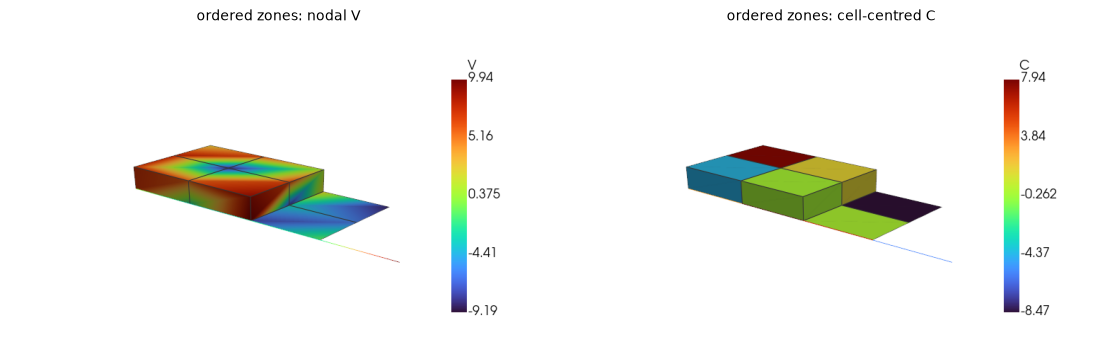

In [2]:
plt_file = path('tecplot/plt', 'ordered.plt')
binary = mp.read(plt_file)
text = mp.read(plt_file.replace('.plt', '.dat'))
print(binary)
print('zones:', [(r.name, len(r.entries)) for r in binary.regions])
same = np.array_equal(binary.points, text.points) and all(
    np.array_equal(a.data, b.data) for a, b in zip(binary.cells, text.cells))
print('.plt reads like its .dat twin:', same)
grid = to_grid(binary, cell_data={'C': binary.cell_data['C']}, point_data={'V': binary.point_data['V']}, lines=True)
gallery([(grid, 'V', 'ordered zones: nodal V', None), (grid, 'C', 'ordered zones: cell-centred C', None)],
        ncols=2, view=(1.0, -1.6, 0.8))

`transient.plt` has two strands at three solution times. As for ASCII files, `time_step` picks one distinct solution time, and `read_sequence` walks them.

In [3]:
transient = path('tecplot/plt', 'transient.plt')
print('solution times:', mp.read_metadata(transient)['time_values'])
for time, step in mp.read_sequence(transient):
    print(f't = {time}: {len(step.points)} points, zones {[r.name for r in step.regions]}, S = {np.round(step.point_data["S"], 3).tolist()}')

solution times: [0.0, 0.5, 1.25]
t = 0.0: 6 points, zones ['strand1_t0'], S = [0.763, -3.135, -2.619, -2.51, 9.749, 2.655]
t = 0.5: 6 points, zones ['strand1_t1'], S = [7.24, -2.231, 9.942, -3.563, 7.828, -7.861]
t = 1.25: 6 points, zones ['strand1_t2'], S = [-8.53, -8.434, 9.612, -0.231, 9.743, 4.503]


## Nastran: coordinate systems

`nastran_op2/static_solid_shell_bar_cord.op2` is `static_solid_shell_bar.op2` with every GRID's `CP` (position) and `CD` (output) system pointed at the file's own `CORD2R`, `CORD2C` and `CORD2S` systems. The reader moves each GRID to the basic system and rotates its displacements; `nastran:cp` and `nastran:cd` still say which system each GRID was given in. `cord_reference.npz` holds pyNastran's basic positions and displacements of the same file.

In [4]:
cord = mp.read(path('nastran_op2', 'static_solid_shell_bar_cord.op2'))
ref = np.load(path('nastran_op2', 'cord_reference.npz'))
print('GRIDs per CP system:', dict(zip(*np.unique(cord.point_data['nastran:cp'], return_counts=True))))
print('max |position - pyNastran|:', np.abs(cord.points - ref['xyz_basic']).max())
rows = np.searchsorted(ref['nids'], ref['displacement_nids'])
disp = np.hstack([cord.point_data['DISPLACEMENT'], cord.point_data['DISPLACEMENT_ROT']])[rows]
print('max |displacement - pyNastran| / max |displacement|:',
      np.abs(disp - ref['displacement_basic']).max() / np.abs(ref['displacement_basic']).max())

GRIDs per CP system: {np.int64(0): np.int64(5), np.int64(2): np.int64(4), np.int64(3): np.int64(4), np.int64(11): np.int64(4), np.int64(12): np.int64(4), np.int64(13): np.int64(4)}
max |position - pyNastran|: 2.220446049250313e-16
max |displacement - pyNastran| / max |displacement|: 5.168312450999794e-16


## Nastran: plies, corners and grid point forces

`nastran_h5/static_elements.h5` (MSC Nastran 2020) has composite shells, solids with corner output and grid point forces. `STRESS:X1` stays the centre value per cell; `STRESS:X1@ply` holds one column per ply (`PLY - 1`) and `STRESS:X@corner` one per node, in the cell's node order. `field_data["nastran:layout:<name>"]` gives the width. The same arrays come out of an OP2.

layout of STRESS:X1@ply: [5, 1]


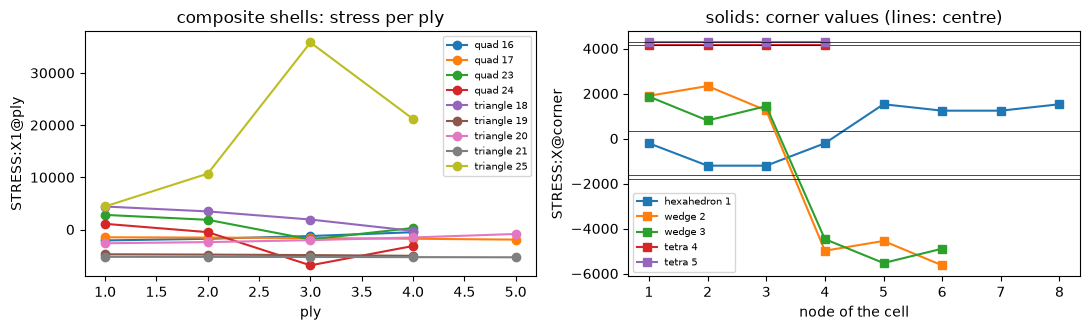

In [5]:
h5 = mp.read(path('nastran_h5', 'static_elements.h5'))
print('layout of STRESS:X1@ply:', h5.field_data['nastran:layout:STRESS:X1@ply'].tolist())
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
for b, plies in enumerate(h5.cell_data['STRESS:X1@ply']):
    for e, row in zip(h5.cell_data['nastran:eid'][b], plies):
        if np.isfinite(row).any():
            a1.plot(np.arange(1, len(row) + 1), row, 'o-', label=f'{h5.cells[b].type} {e}')
a1.set(xlabel='ply', ylabel='STRESS:X1@ply', title='composite shells: stress per ply')
a1.legend(fontsize=7)
for b, corners in enumerate(h5.cell_data['STRESS:X@corner']):
    for e, row in zip(h5.cell_data['nastran:eid'][b], corners):
        if np.isfinite(row).any():
            n = np.isfinite(row).sum()
            a2.plot(np.arange(1, n + 1), row[:n], 's-', label=f'{h5.cells[b].type} {e}')
            a2.axhline(h5.cell_data['STRESS:X'][b][list(h5.cell_data['nastran:eid'][b]).index(e)], lw=0.5, color='k')
a2.set(xlabel='node of the cell', ylabel='STRESS:X@corner', title='solids: corner values (lines: centre)')
a2.legend(fontsize=7)
plt.tight_layout()
plt.show()

`GRID_FORCE:F1`...`M3` hold the grid point forces each element applies to its nodes, again one column per node of the cell. The rows of no element are point data named after their label, without its asterisks: `GRID_FORCE:TOTALS:F1`, `GRID_FORCE:APP-LOAD:F1`, `GRID_FORCE:F-OF-SPC:F1`... Every GRID is in equilibrium, so its totals vanish to round-off.

In [6]:
print(sorted(k for k in h5.point_data if k.startswith('GRID_FORCE')))
totals = np.column_stack([h5.point_data[f'GRID_FORCE:TOTALS:F{k}'] for k in (1, 2, 3)])
loads = np.column_stack([h5.point_data[f'GRID_FORCE:APP-LOAD:F{k}'] for k in (1, 2, 3)])
print('largest |total force| at a GRID:', np.nanmax(np.abs(totals)), '| largest applied load:', np.nanmax(np.abs(loads)))

['GRID_FORCE:APP-LOAD:F1', 'GRID_FORCE:APP-LOAD:F2', 'GRID_FORCE:APP-LOAD:F3', 'GRID_FORCE:APP-LOAD:M1', 'GRID_FORCE:APP-LOAD:M2', 'GRID_FORCE:APP-LOAD:M3', 'GRID_FORCE:F-OF-SPC:F1', 'GRID_FORCE:F-OF-SPC:F2', 'GRID_FORCE:F-OF-SPC:F3', 'GRID_FORCE:F-OF-SPC:M1', 'GRID_FORCE:F-OF-SPC:M2', 'GRID_FORCE:F-OF-SPC:M3', 'GRID_FORCE:TOTALS:F1', 'GRID_FORCE:TOTALS:F2', 'GRID_FORCE:TOTALS:F3', 'GRID_FORCE:TOTALS:M1', 'GRID_FORCE:TOTALS:M2', 'GRID_FORCE:TOTALS:M3']
largest |total force| at a GRID: 4.9681148084346205e-11 | largest applied load: 9800.0


## Fluent: a face-based `.msh`

`msh/insulated-4.1.msh` is a 2-D gmsh mesh of an insulated wire: two triangle regions, `wire` and `insulation`, and the `convection` boundary. Written as Fluent `.msh`, every face (an edge, in 2-D) appears once with the cells on either side, the cells in one zone per region, the interior faces in one zone and each boundary zone a wall zone. The zones come from `cell_data["ansys:zone"]`, here the region tags (without it, each block is a zone), and a zone takes the name of the region with its tag. Reading it back rebuilds the cells from their faces, with the same area.

regions: [('convection', 3, 1), ('insulation', 2, 2), ('wire', 1, 2)]
zones read back: [('convection', 3, 1, 21), ('insulation', 2, 2, 66), ('wire', 1, 2, 45)]
area: 27.854364 before, 27.854364 after


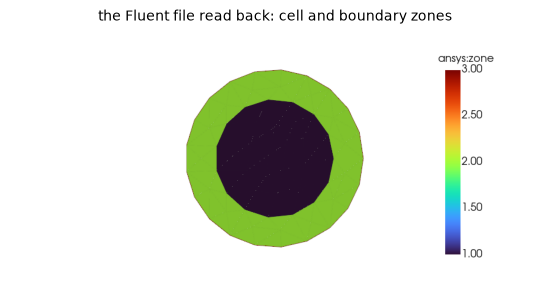

In [7]:
source = mp.read(path('msh', 'insulated-4.1.msh'))
print('regions:', [(r.name, r.tag, r.dim) for r in source.regions])
# One Fluent zone per region, the region's tag as its id: `convection` spans three line blocks.
flat = np.zeros(sum(len(c.data) for c in source.cells), dtype=np.int64)
for r in source.regions:
    flat[r.entries] = r.tag
bounds = np.cumsum([0] + [len(c.data) for c in source.cells])
source.cell_data['ansys:zone'] = [flat[a:b] for a, b in zip(bounds[:-1], bounds[1:])]
fluent_file = os.path.join(TMP, 'insulated.msh')
mp.write(fluent_file, source, file_format='ansys', binary=True)
fluent = mp.read(fluent_file, file_format='ansys')
print('zones read back:', [(r.name, r.tag, r.dim, len(r.entries)) for r in fluent.regions])


def area(mesh):
    total = 0.0
    for c in mesh.cells:
        if c.type == 'triangle':
            p = mesh.points[c.data][:, :, :2]
            e1, e2 = p[:, 1] - p[:, 0], p[:, 2] - p[:, 0]
            total += np.abs(e1[:, 0] * e2[:, 1] - e1[:, 1] * e2[:, 0]).sum() / 2
    return total


print(f'area: {area(source):.6f} before, {area(fluent):.6f} after')
zone = [z.astype(float) for z in fluent.cell_data['ansys:zone']]
grid = to_grid(fluent, cell_data={'ansys:zone': zone}, lines=True)
gallery([(grid, 'ansys:zone', 'the Fluent file read back: cell and boundary zones', None)], ncols=1, size=(900, 440),
        view=(0, 0, 1))

## Elmer: a partitioned write

`partition_labels` gives each cell a part; with those labels as `cell_data["partition:part"]`, the Elmer writer adds `partitioning.N/part.k.*` beside the serial mesh, in ElmerGrid's layout: each part's elements, its nodes, the boundary elements of its cells and the nodes it shares with other parts. Here the insulated wire is cut into three parts. ElmerSolver runs such a directory with one MPI process per part (checked with two parts; see the Elmer format page), and reading the directory merges the parts back, labels included.

['mesh.boundary', 'mesh.elements', 'mesh.header', 'mesh.names', 'mesh.nodes', 'partitioning.3']
['part.1.boundary', 'part.1.elements', 'part.1.header', 'part.1.nodes', 'part.1.shared', 'part.2.boundary', 'part.2.elements', 'part.2.header', 'part.2.nodes', 'part.2.shared', 'part.3.boundary', 'part.3.elements', 'part.3.header', 'part.3.nodes', 'part.3.shared']
part.1.header: ['33', '36', '8', '2', '303', '36', '202', '8', '20', '0']
blocks read back: [('triangle', 111), ('line', 21)]
triangle labels read back: True
merged parts: [('triangle', 111), ('line', 21)]


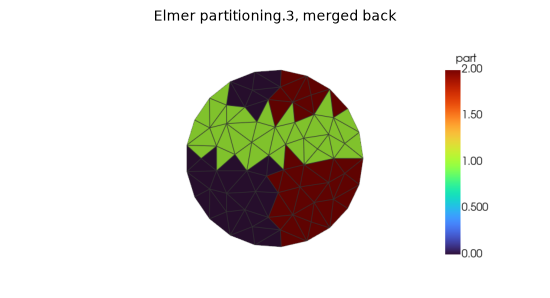

In [8]:
mesh = mp.read(path('msh', 'insulated-4.1.msh'))
mesh.cell_data['partition:part'] = mp.partition_labels(mesh, 3)
out = os.path.join(TMP, 'elmer_parts')
mp.write(out, mesh, file_format='elmer')
print(sorted(os.listdir(out)))
print(sorted(os.listdir(os.path.join(out, 'partitioning.3'))))
with open(os.path.join(out, 'partitioning.3', 'part.1.header')) as f:
    print('part.1.header:', f.read().split())
serial = mp.read(out)  # the serial mesh, labelled from the one partitioning beside it
tri_labels = lambda m: np.concatenate([l for c, l in zip(m.cells, m.cell_data['partition:part']) if c.type == 'triangle'])
print('blocks read back:', [(c.type, len(c.data)) for c in serial.cells])
print('triangle labels read back:', np.array_equal(tri_labels(serial), tri_labels(mesh)))
back = mp.read(os.path.join(out, 'partitioning.3'))  # the parts merged, in part order
print('merged parts:', [(c.type, len(c.data)) for c in back.cells])
grid = to_grid(back, cell_data={'part': [p.astype(float) for p in back.cell_data['partition:part']]})
gallery([(grid, 'part', 'Elmer partitioning.3, merged back', None)], ncols=1, size=(900, 440), view=(0, 0, 1))

ElmerGrid's binary meshes (`ElmerGrid -bin`, and `-sbin` for single-precision nodes) read like the text ones. `elmer/tet10_two_bodies_bin` is ElmerGrid's binary output of the text mesh `elmer/tet10_two_bodies`.

In [9]:
binary_mesh = mp.read(path('elmer', 'tet10_two_bodies_bin'))
print(sorted(f for f in os.listdir(path('elmer', 'tet10_two_bodies_bin'))))
text_mesh = mp.read(path('elmer', 'tet10_two_bodies'))
print('same points and cells as the text mesh:', np.array_equal(binary_mesh.points, text_mesh.points)
      and all(np.array_equal(a.data, b.data) for a, b in zip(binary_mesh.cells, text_mesh.cells)))

['mesh.boundary.bin', 'mesh.elements.bin', 'mesh.header', 'mesh.names', 'mesh.nodes.bin']
same points and cells as the text mesh: True


## FEBio: MeshData

Point and cell data are written as FEBio `<MeshData>`, each array over its own node or element set named `meshdata:<name>`, which the reader recognises and makes no region of. FEBio uses such an array wherever a parameter names it as a map, for example `<E type="map">stiffness</E>`.

In [10]:
block = mp.read(path('febio', 'block_v30.feb'))
centres = [block.points[c.data].mean(axis=1) for c in block.cells]
block.cell_data['stiffness'] = [1.0 + x[:, 0] for x in centres]
block.point_data['temperature'] = 20.0 + 5.0 * block.points[:, 2]
feb = os.path.join(TMP, 'block.feb')
mp.write(feb, block)
text = open(feb).read()
print(text[text.index('<MeshData>'):text.index('</MeshData>') + 11][:600])
again = mp.read(feb)
print('regions unchanged:', sorted(r.name for r in again.regions) == sorted(r.name for r in block.regions))
print('arrays read back:', sorted(again.point_data), sorted(again.cell_data))

<MeshData>
		<NodeData name="temperature" node_set="meshdata:temperature" data_type="scalar">
			<node lid="1">20</node>
			<node lid="2">20</node>
			<node lid="3">20</node>
			<node lid="4">20</node>
			<node lid="5">25</node>
			<node lid="6">25</node>
			<node lid="7">25</node>
			<node lid="8">25</node>
			<node lid="9">20</node>
			<node lid="10">20</node>
			<node lid="11">25</node>
			<node lid="12">25</node>
		</NodeData>
		<ElementData name="stiffness" elem_set="meshdata:stiffness" data_type="scalar">
			<e lid="1">1.5</e>
			<e lid="2">2.5</e>
		</ElementData>
		<ElementData name="t
regions unchanged: True
arrays read back: ['temperature'] ['stiffness', 'thickness']


## FEBio `.xplt`: surface variables

`febio/xplt/xplt_surface.xplt` is FEBio 4.12's plot file for a two-hexahedron bar under pressure on its end and on its top, with facet and surface variables plotted. Each data surface becomes a block of facet cells after the domains, with a cell region of its name, and its variables are cell data there (NaN elsewhere). `facet area` is the area of each deformed facet and `surface area` their sum.

[('hexahedron', 2), ('quad', 1), ('quad', 2)] | xplt:surface = [[0, 0], [1], [2, 2]]
facet area on "top": [1.14274, 1.05083] | surface area: [2.19356, 2.19356]


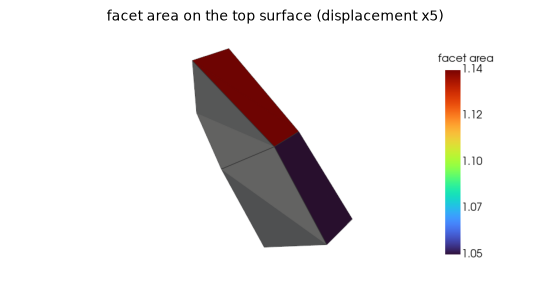

In [11]:
xp = path('febio/xplt', 'xplt_surface.xplt')
last = mp.read(xp, time_step=-1)
print([(c.type, len(c.data)) for c in last.cells], '| xplt:surface =', [a.tolist() for a in last.cell_data['xplt:surface']])
print('facet area on "top":', last.cell_data['facet area'][2].round(5).tolist(),
      '| surface area:', last.cell_data['surface area'][2].round(5).tolist())
u = last.point_data['displacement']
grid = to_grid(last, point_data={'u': u}, cell_data={'facet area': last.cell_data['facet area']})
gallery([(grid.warp_by_vector('u', factor=5.0), 'facet area', 'facet area on the top surface (displacement x5)', None)],
        ncols=1, size=(900, 440), view=(1.0, -1.4, 0.9))

## FEBio `.xplt`: a remeshed run

`febio/xplt/xplt_remesh.xplt` comes from a bar pulled along x with a `hex_refine` mesh adaptor that refines it after every step. FEBio writes a new mesh before the states that use it, and each state is read on its own mesh, so the steps of a sequence differ in points and cells.

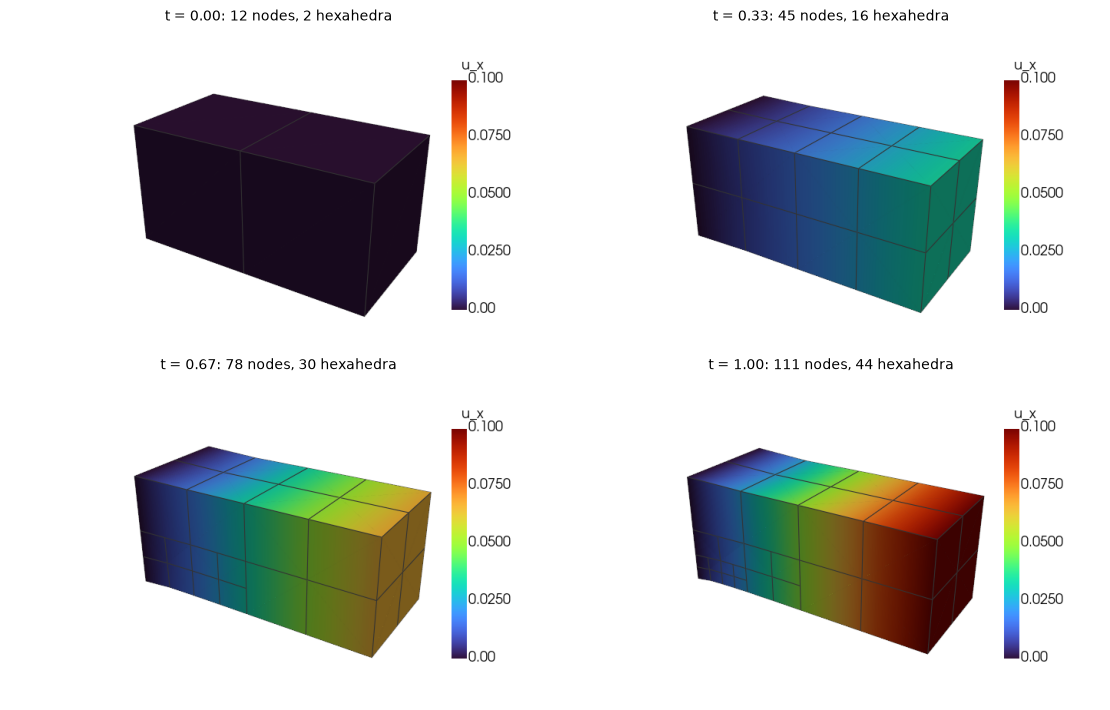

In [12]:
items = []
for time, state in mp.read_sequence(path('febio/xplt', 'xplt_remesh.xplt')):
    u = state.point_data['displacement']
    grid = to_grid(state, point_data={'u': u, 'u_x': u[:, 0]})
    items.append((grid.warp_by_vector('u', factor=3.0), 'u_x',
                  f't = {time:.2f}: {len(state.points)} nodes, {len(state.cells[0].data)} hexahedra', (0.0, 0.1)))
gallery(items, ncols=2, size=(700, 420), view=(1.0, -1.6, 0.9))